In [1]:
# gradient_matching_mnist.py

import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# ============================================================
# 1. Configuration
# ============================================================

SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# MNIST
REAL_BATCH_SIZE = 50

# Synthetic dataset
NUM_SYNTH = 50

# Number of parameter regions used during synthetic optimization
NUM_TRAIN_REGIONS = 8

# Number of unseen parameter regions for evaluation
NUM_TEST_REGIONS = 4

# Hidden layer
HIDDEN = 128

# Optimization
STEPS = 1500
LR = 0.1

# Gradient matching
COSINE_WEIGHT = 1.0
MSE_WEIGHT = 0.1

# How strongly parameters are perturbed around the anchor model
REGION_STD = 0.10

# Print every N iterations
PRINT_EVERY = 100


# ============================================================
# 2. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", DEVICE)


# ============================================================
# 3. Model
# ============================================================

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, 10)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 4. Loss supporting soft labels
# ============================================================

def soft_cross_entropy(logits, targets):
    """
    logits:
        [B, 10]

    targets:
        [B, 10]
        soft labels whose rows approximately sum to 1.
    """

    log_probs = F.log_softmax(logits, dim=1)

    loss = -(targets * log_probs).sum(dim=1)

    return loss.mean()


# ============================================================
# 5. Flatten gradients
# ============================================================

def flatten_grads(grads):
    return torch.cat([
        g.reshape(-1)
        for g in grads
    ])


# ============================================================
# 6. Gradient of a dataset batch
# ============================================================

def compute_gradient(
    model,
    x,
    y,
    create_graph=False
):
    """
    Computes gradient of loss w.r.t. model parameters.

    create_graph=True is required when we want to
    differentiate the gradient-matching loss w.r.t.
    the synthetic data.
    """

    logits = model(x)

    loss = soft_cross_entropy(logits, y)

    grads = torch.autograd.grad(
        loss,
        tuple(model.parameters()),
        create_graph=create_graph,
        retain_graph=create_graph
    )

    return flatten_grads(grads)


# ============================================================
# 7. Gradient matching distance
# ============================================================

def gradient_distance(g_syn, g_real):
    """
    Compare two gradients.

    Cosine term:
        1 - cos(g_syn, g_real)

    Normalized MSE:
        ||g_syn - g_real||^2 / ||g_real||^2
    """

    g_syn_norm = g_syn / (g_syn.norm() + 1e-8)
    g_real_norm = g_real / (g_real.norm() + 1e-8)

    cosine_loss = 1.0 - torch.sum(
        g_syn_norm * g_real_norm
    )

    mse_loss = (
        (g_syn_norm - g_real_norm) ** 2
    ).mean()

    return (
        COSINE_WEIGHT * cosine_loss
        + MSE_WEIGHT * mse_loss
    )


# ============================================================
# 8. Create parameter regions
# ============================================================

def make_parameter_regions(
    anchor_model,
    num_regions,
    std
):
    """
    Create several nearby parameter regions.

    Every region is a different model initialization,
    centered around the same anchor parameters.
    """

    regions = []

    anchor_state = copy.deepcopy(
        anchor_model.state_dict()
    )

    for _ in range(num_regions):

        model = MLP().to(DEVICE)

        state = {}

        for name, tensor in anchor_state.items():

            state[name] = (
                tensor
                + std * torch.randn_like(tensor)
            )

        model.load_state_dict(state)

        regions.append(model)

    return regions


# ============================================================
# 9. Load MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

loader_iter = iter(train_loader)


# ============================================================
# 10. Initial anchor model
# ============================================================

anchor_model = MLP().to(DEVICE)


# ============================================================
# 11. Create train parameter regions
# ============================================================

train_regions = make_parameter_regions(
    anchor_model,
    NUM_TRAIN_REGIONS,
    REGION_STD
)


# ============================================================
# 12. Create unseen test parameter regions
# ============================================================

test_regions = make_parameter_regions(
    anchor_model,
    NUM_TEST_REGIONS,
    REGION_STD
)


# ============================================================
# 13. Pick fixed real batches
# ============================================================

real_batches = []

for k in range(NUM_TRAIN_REGIONS):

    try:
        x_real, y_real = next(loader_iter)

    except StopIteration:
        loader_iter = iter(train_loader)
        x_real, y_real = next(loader_iter)

    x_real = x_real.view(
        x_real.size(0),
        -1
    ).to(DEVICE)

    y_real = F.one_hot(
        y_real,
        num_classes=10
    ).float().to(DEVICE)

    real_batches.append(
        (x_real, y_real)
    )


# ============================================================
# 14. Initialize synthetic data
# ============================================================

# Random synthetic images.
#
# Shape:
#   [50, 784]

synthetic_x = torch.randn(
    NUM_SYNTH,
    784,
    device=DEVICE,
    requires_grad=True
)

# Learnable label logits.
#
# We optimize logits rather than probabilities.
# Softmax converts them into 10-dimensional labels.

synthetic_y_logits = torch.randn(
    NUM_SYNTH,
    10,
    device=DEVICE,
    requires_grad=True
)


# ============================================================
# 15. Synthetic optimizer
# ============================================================

optimizer = torch.optim.Adam(
    [
        synthetic_x,
        synthetic_y_logits
    ],
    lr=LR
)


# ============================================================
# 16. Precompute real gradients
# ============================================================

print()
print("Precomputing real gradients...")

real_gradients = []

for k, model in enumerate(train_regions):

    x_real, y_real = real_batches[k]

    g_real = compute_gradient(
        model,
        x_real,
        y_real,
        create_graph=False
    )

    # No need to keep graph.
    g_real = g_real.detach()

    real_gradients.append(g_real)


print("Done.")


# ============================================================
# 17. Synthetic optimization
# ============================================================

print()
print("Starting gradient matching...")
print()

for step in range(STEPS):

    optimizer.zero_grad()

    # Convert label logits to probability distributions
    synthetic_y = F.softmax(
        synthetic_y_logits,
        dim=1
    )

    total_loss = 0.0

    # --------------------------------------------------------
    # Match gradients in EVERY parameter region
    # --------------------------------------------------------

    for k, model in enumerate(train_regions):

        g_real = real_gradients[k]

        g_syn = compute_gradient(
            model,
            synthetic_x,
            synthetic_y,
            create_graph=True
        )

        loss_k = gradient_distance(
            g_syn,
            g_real
        )

        total_loss = total_loss + loss_k

    # Average across parameter regions
    total_loss = (
        total_loss / NUM_TRAIN_REGIONS
    )

    # --------------------------------------------------------
    # Optimize synthetic tensor
    # --------------------------------------------------------

    total_loss.backward()

    optimizer.step()

    # Optional image-value constraint
    with torch.no_grad():
        synthetic_x.clamp_(
            -3.0,
            3.0
        )

    if step % PRINT_EVERY == 0:

        print(
            f"step={step:4d} "
            f"loss={total_loss.item():.6f}"
        )


# ============================================================
# 18. Evaluate gradient similarity
# ============================================================

def cosine_similarity(a, b):

    a = a / (a.norm() + 1e-8)
    b = b / (b.norm() + 1e-8)

    return torch.sum(a * b).item()


@torch.no_grad()
def get_hard_labels(y_logits):

    return y_logits.argmax(dim=1)


print()
print("=" * 70)
print("Evaluation")
print("=" * 70)


# Synthetic labels
synthetic_y = F.softmax(
    synthetic_y_logits,
    dim=1
)

# ------------------------------------------------------------
# Train regions
# ------------------------------------------------------------

train_scores = []

for k, model in enumerate(train_regions):

    x_real, y_real = real_batches[k]

    # Real gradient
    g_real = real_gradients[k]

    # Synthetic gradient
    #
    # We don't need higher-order gradients during evaluation.
    g_syn = compute_gradient(
        model,
        synthetic_x,
        synthetic_y,
        create_graph=False
    )

    score = cosine_similarity(
        g_syn.detach(),
        g_real
    )

    train_scores.append(score)

    print(
        f"Train region {k:2d}: "
        f"cosine similarity = {score:.6f}"
    )


# ------------------------------------------------------------
# Unseen parameter regions
# ------------------------------------------------------------

print()
print("Unseen parameter regions:")

# Use one fixed real batch for evaluating
# the unseen parameter regions.

x_test_real, y_test_real = real_batches[0]

test_scores = []

for k, model in enumerate(test_regions):

    # Real gradient at this NEW parameter region
    g_real = compute_gradient(
        model,
        x_test_real,
        y_test_real,
        create_graph=False
    ).detach()

    # Synthetic gradient at same NEW parameter region
    g_syn = compute_gradient(
        model,
        synthetic_x,
        synthetic_y,
        create_graph=False
    )

    score = cosine_similarity(
        g_syn.detach(),
        g_real
    )

    test_scores.append(score)

    print(
        f"Test region {k:2d}: "
        f"cosine similarity = {score:.6f}"
    )


# ============================================================
# 19. Summary
# ============================================================

print()
print("=" * 70)

print(
    "Mean train-region similarity:",
    np.mean(train_scores)
)

print(
    "Mean unseen-region similarity:",
    np.mean(test_scores)
)

print("=" * 70)


# ============================================================
# 20. Inspect synthetic labels
# ============================================================

hard_labels = get_hard_labels(
    synthetic_y_logits
)

print()
print("Synthetic hard-label distribution:")

for digit in range(10):

    count = (
        hard_labels == digit
    ).sum().item()

    print(
        f"digit {digit}: {count}"
    )

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]



Precomputing real gradients...
Done.

Starting gradient matching...

step=   0 loss=0.714741
step= 100 loss=0.087713
step= 200 loss=0.070677
step= 300 loss=0.062038
step= 400 loss=0.058315
step= 500 loss=0.056441
step= 600 loss=0.054654
step= 700 loss=0.054554
step= 800 loss=0.053063
step= 900 loss=0.051654
step=1000 loss=0.050328
step=1100 loss=0.051286
step=1200 loss=0.050395
step=1300 loss=0.050284
step=1400 loss=0.050139

Evaluation
Train region  0: cosine similarity = 0.941870
Train region  1: cosine similarity = 0.940813
Train region  2: cosine similarity = 0.960763
Train region  3: cosine similarity = 0.955311
Train region  4: cosine similarity = 0.974102
Train region  5: cosine similarity = 0.937553
Train region  6: cosine similarity = 0.941851
Train region  7: cosine similarity = 0.946535

Unseen parameter regions:
Test region  0: cosine similarity = 0.813557
Test region  1: cosine similarity = 0.741424
Test region  2: cosine similarity = 0.773484
Test region  3: cosine simil


Training 1-region model
step    0 | loss 0.98155
step  100 | loss 0.07821
step  200 | loss 0.05745
step  300 | loss 0.05738
step  400 | loss 0.05485
step  500 | loss 0.06031
step  600 | loss 0.05812
step  700 | loss 0.05831
step  800 | loss 0.05634
step  900 | loss 0.06176
step 1000 | loss 0.06336
step 1100 | loss 0.05872

Training 8-region model
step    0 | loss 0.87757
step  100 | loss 0.14718
step  200 | loss 0.11595
step  300 | loss 0.10638
step  400 | loss 0.10205
step  500 | loss 0.10051
step  600 | loss 0.09707
step  700 | loss 0.09628
step  800 | loss 0.09571
step  900 | loss 0.09538
step 1000 | loss 0.09418
step 1100 | loss 0.09407

Training 32-region model
step    0 | loss 0.74197
step  100 | loss 0.14651
step  200 | loss 0.10789
step  300 | loss 0.09745
step  400 | loss 0.09260
step  500 | loss 0.08980
step  600 | loss 0.08771
step  700 | loss 0.08569
step  800 | loss 0.08483
step  900 | loss 0.08359
step 1000 | loss 0.08241
step 1100 | loss 0.08178

Synthetic-data training

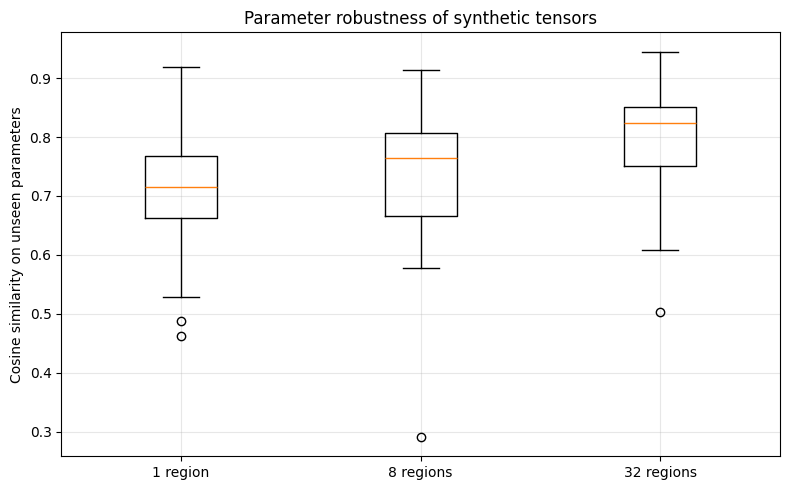

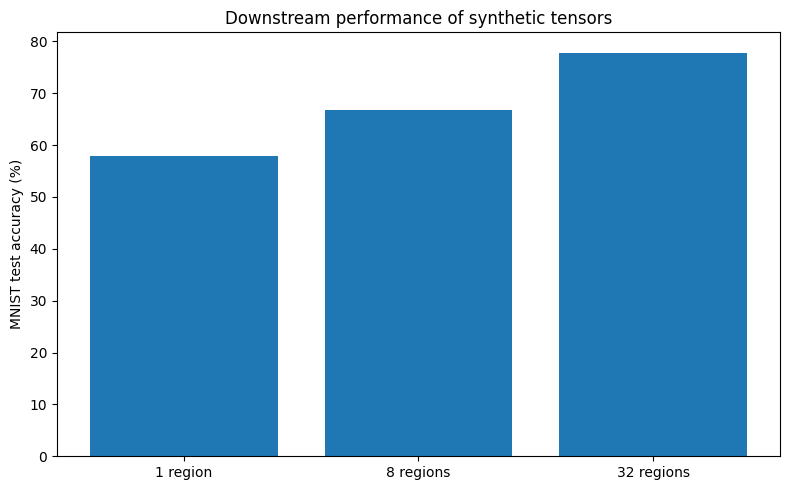

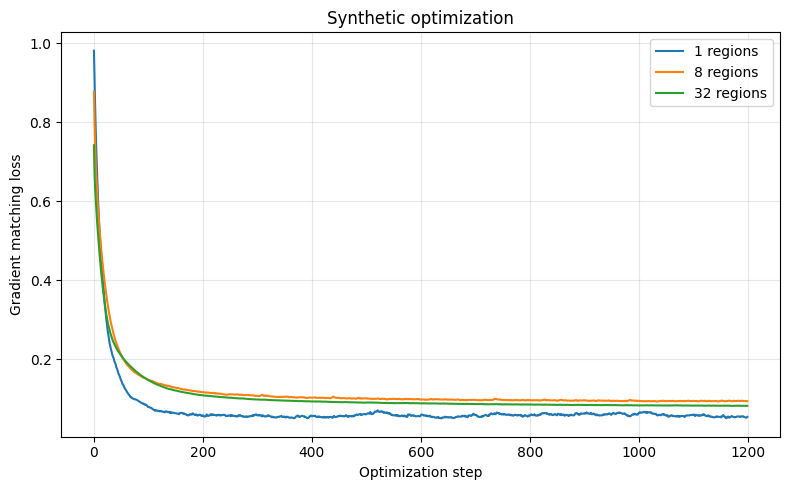

In [2]:
# ============================================================
# MNIST Multi-Region Gradient Matching Experiment
#
# Compare:
#   1. Single-point gradient matching
#   2. 8-region gradient matching
#   3. 32-region gradient matching
#
# Evaluate:
#   - Gradient cosine similarity on unseen parameters
#   - Accuracy after training on synthetic data
#
# ============================================================

import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# Configuration
# ============================================================

SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_SYNTH = 50
HIDDEN = 128

# Training regions
REGION_COUNTS = [1, 8, 32]

# Number of unseen parameter models
NUM_TEST_REGIONS = 20

# Parameter-space radius
LOCAL_STD = 0.05
WIDE_STD = 0.20

# Synthetic optimization
STEPS = 1200
LR = 0.05

REAL_BATCH_SIZE = 50

# Evaluation training
EVAL_STEPS = 100
EVAL_LR = 0.1

PRINT_EVERY = 100


# ============================================================
# Seed
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# Model
# ============================================================

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, 10)

    def forward(self, x):

        x = F.relu(self.fc1(x))

        return self.fc2(x)


# ============================================================
# Soft-label cross entropy
# ============================================================

def soft_cross_entropy(logits, targets):

    log_probs = F.log_softmax(
        logits,
        dim=1
    )

    return -(targets * log_probs).sum(dim=1).mean()


# ============================================================
# Flatten gradient
# ============================================================

def flatten_grads(grads):

    return torch.cat([
        g.reshape(-1)
        for g in grads
    ])


# ============================================================
# Functional forward
#
# Instead of modifying model parameters, we explicitly
# provide parameters to the forward function.
# ============================================================

def functional_logits(
    x,
    params
):

    w1, b1, w2, b2 = params

    h = F.linear(
        x,
        w1,
        b1
    )

    h = F.relu(h)

    return F.linear(
        h,
        w2,
        b2
    )


# ============================================================
# Compute gradient
# ============================================================

def compute_gradient(
    params,
    x,
    y,
    create_graph
):

    logits = functional_logits(
        x,
        params
    )

    loss = soft_cross_entropy(
        logits,
        y
    )

    grads = torch.autograd.grad(
        loss,
        params,
        create_graph=create_graph
    )

    return flatten_grads(grads)


# ============================================================
# Cosine similarity
# ============================================================

def cosine_similarity(a, b):

    a = a / (a.norm() + 1e-8)
    b = b / (b.norm() + 1e-8)

    return torch.sum(a * b)


# ============================================================
# Gradient matching loss
# ============================================================

def gradient_matching_loss(
    g_syn,
    g_real
):

    g_syn_n = g_syn / (
        g_syn.norm() + 1e-8
    )

    g_real_n = g_real / (
        g_real.norm() + 1e-8
    )

    cosine_loss = 1.0 - (
        g_syn_n * g_real_n
    ).sum()

    mse_loss = (
        g_syn_n - g_real_n
    ).pow(2).mean()

    return cosine_loss + 0.1 * mse_loss


# ============================================================
# Model -> parameter tuple
# ============================================================

def model_parameters(model):

    return tuple(
        p.detach().clone()
        for p in model.parameters()
    )


# ============================================================
# Create parameter region
# ============================================================

def perturb_parameters(
    base_params,
    std
):

    return tuple(
        (
            p
            + std * torch.randn_like(p)
        ).requires_grad_(True)
        for p in base_params
    )


# ============================================================
# Load MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)


# ============================================================
# Get fixed real batches
# ============================================================

loader_iter = iter(train_loader)

real_batches = []

for _ in range(32):

    try:
        x, y = next(loader_iter)

    except StopIteration:
        loader_iter = iter(train_loader)
        x, y = next(loader_iter)

    x = x.view(
        x.size(0),
        -1
    ).to(DEVICE)

    y = F.one_hot(
        y,
        10
    ).float().to(DEVICE)

    real_batches.append(
        (x, y)
    )


# ============================================================
# Base parameter
# ============================================================

base_model = MLP().to(DEVICE)

base_params = model_parameters(
    base_model
)


# ============================================================
# Build parameter regions
# ============================================================

def build_regions(
    num_regions,
    std
):

    regions = []

    for _ in range(num_regions):

        params = perturb_parameters(
            base_params,
            std
        )

        regions.append(params)

    return regions


# ============================================================
# Precompute real gradients
# ============================================================

def precompute_real_gradients(
    regions
):

    gradients = []

    for i, params in enumerate(regions):

        x, y = real_batches[
            i % len(real_batches)
        ]

        g = compute_gradient(
            params,
            x,
            y,
            create_graph=False
        )

        gradients.append(
            g.detach()
        )

    return gradients


# ============================================================
# Synthetic initialization
# ============================================================

def initialize_synthetic():

    x = torch.randn(
        NUM_SYNTH,
        784,
        device=DEVICE,
        requires_grad=True
    )

    y_logits = torch.randn(
        NUM_SYNTH,
        10,
        device=DEVICE,
        requires_grad=True
    )

    return x, y_logits


# ============================================================
# Train one synthetic dataset
# ============================================================

def train_synthetic(
    num_regions,
    std
):

    print()
    print(
        f"Training {num_regions}-region model"
    )

    regions = build_regions(
        num_regions,
        std
    )

    real_gradients = (
        precompute_real_gradients(
            regions
        )
    )

    synthetic_x, synthetic_y_logits = (
        initialize_synthetic()
    )

    optimizer = torch.optim.Adam(
        [
            synthetic_x,
            synthetic_y_logits
        ],
        lr=LR
    )

    loss_history = []

    for step in range(STEPS):

        optimizer.zero_grad()

        synthetic_y = F.softmax(
            synthetic_y_logits,
            dim=1
        )

        total_loss = 0.0

        for i, params in enumerate(regions):

            g_real = real_gradients[i]

            g_syn = compute_gradient(
                params,
                synthetic_x,
                synthetic_y,
                create_graph=True
            )

            loss = gradient_matching_loss(
                g_syn,
                g_real
            )

            total_loss = (
                total_loss + loss
            )

        total_loss = (
            total_loss / num_regions
        )

        total_loss.backward()

        optimizer.step()

        with torch.no_grad():

            synthetic_x.clamp_(
                -3.0,
                3.0
            )

        loss_history.append(
            total_loss.item()
        )

        if step % PRINT_EVERY == 0:

            print(
                f"step {step:4d} | "
                f"loss {total_loss.item():.5f}"
            )

    return {
        "x": synthetic_x.detach(),
        "y_logits": synthetic_y_logits.detach(),
        "loss": loss_history,
        "regions": regions
    }


# ============================================================
# Train all three methods
# ============================================================

experiments = {}

for num_regions in REGION_COUNTS:

    # Wider parameter coverage for larger experiment
    if num_regions == 1:
        std = 0.0

    elif num_regions == 8:
        std = LOCAL_STD

    else:
        std = WIDE_STD

    experiments[num_regions] = train_synthetic(
        num_regions,
        std
    )


# ============================================================
# Unseen parameter regions
# ============================================================

test_regions = []

for _ in range(NUM_TEST_REGIONS):

    params = perturb_parameters(
        base_params,
        WIDE_STD
    )

    test_regions.append(params)


# ============================================================
# Evaluate gradient similarity
# ============================================================

def evaluate_gradient_similarity(
    experiment
):

    synthetic_x = experiment["x"]

    synthetic_y = F.softmax(
        experiment["y_logits"],
        dim=1
    )

    scores = []

    for i, params in enumerate(
        test_regions
    ):

        # Real data
        x_real, y_real = real_batches[
            i % len(real_batches)
        ]

        g_real = compute_gradient(
            params,
            x_real,
            y_real,
            create_graph=False
        ).detach()

        # Synthetic data
        g_syn = compute_gradient(
            params,
            synthetic_x,
            synthetic_y,
            create_graph=False
        ).detach()

        score = cosine_similarity(
            g_syn,
            g_real
        ).item()

        scores.append(score)

    return scores


gradient_results = {}

for num_regions, experiment in experiments.items():

    scores = evaluate_gradient_similarity(
        experiment
    )

    gradient_results[num_regions] = scores


# ============================================================
# Evaluation model
# ============================================================

def accuracy(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.view(
                x.size(0),
                -1
            ).to(DEVICE)

            y = y.to(DEVICE)

            logits = model(x)

            pred = logits.argmax(
                dim=1
            )

            correct += (
                pred == y
            ).sum().item()

            total += y.numel()

    return correct / total


# ============================================================
# Train fresh model using synthetic dataset
# ============================================================

def train_on_synthetic(
    experiment,
    steps=EVAL_STEPS
):

    model = MLP().to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=EVAL_LR
    )

    x_syn = experiment["x"]

    y_syn = F.softmax(
        experiment["y_logits"],
        dim=1
    )

    for _ in range(steps):

        optimizer.zero_grad()

        logits = model(x_syn)

        loss = soft_cross_entropy(
            logits,
            y_syn
        )

        loss.backward()

        optimizer.step()

    return accuracy(model)


# ============================================================
# Accuracy evaluation
# ============================================================

accuracy_results = {}

print()
print("=" * 70)
print("Synthetic-data training evaluation")
print("=" * 70)

for num_regions, experiment in experiments.items():

    acc = train_on_synthetic(
        experiment
    )

    accuracy_results[num_regions] = acc

    print(
        f"{num_regions:2d} regions: "
        f"{acc * 100:.2f}%"
    )


# ============================================================
# Summary
# ============================================================

print()
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

for num_regions in REGION_COUNTS:

    mean_cos = np.mean(
        gradient_results[num_regions]
    )

    std_cos = np.std(
        gradient_results[num_regions]
    )

    acc = accuracy_results[
        num_regions
    ]

    print(
        f"{num_regions:2d} regions | "
        f"unseen cosine = "
        f"{mean_cos:.4f} ± {std_cos:.4f} | "
        f"accuracy = {acc * 100:.2f}%"
    )


# ============================================================
# Plot 1: Gradient similarity
# ============================================================

plt.figure(figsize=(8, 5))

positions = np.arange(
    len(REGION_COUNTS)
)

data = [
    gradient_results[n]
    for n in REGION_COUNTS
]

plt.boxplot(
    data,
    positions=positions
)

plt.xticks(
    positions,
    [
        "1 region",
        "8 regions",
        "32 regions"
    ]
)

plt.ylabel(
    "Cosine similarity on unseen parameters"
)

plt.title(
    "Parameter robustness of synthetic tensors"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "gradient_similarity.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot 2: Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

accuracies = [
    accuracy_results[n] * 100
    for n in REGION_COUNTS
]

plt.bar(
    [
        "1 region",
        "8 regions",
        "32 regions"
    ],
    accuracies
)

plt.ylabel(
    "MNIST test accuracy (%)"
)

plt.title(
    "Downstream performance of synthetic tensors"
)

plt.tight_layout()

plt.savefig(
    "synthetic_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot 3: Gradient matching loss
# ============================================================

plt.figure(figsize=(8, 5))

for num_regions in REGION_COUNTS:

    plt.plot(
        experiments[num_regions]["loss"],
        label=f"{num_regions} regions"
    )

plt.xlabel(
    "Optimization step"
)

plt.ylabel(
    "Gradient matching loss"
)

plt.title(
    "Synthetic optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "training_loss.png",
    dpi=150
)

plt.show()

Device: cuda
Real batch: torch.Size([500, 784]) torch.Size([500, 10])

Training SINGLE-POINT synthetic tensor
[single] step=   0 loss=0.983828
[single] step= 100 loss=0.061333
[single] step= 200 loss=0.040433
[single] step= 300 loss=0.036678
[single] step= 400 loss=0.038291
[single] step= 500 loss=0.039927
[single] step= 600 loss=0.040623
[single] step= 700 loss=0.041351
[single] step= 800 loss=0.039759
[single] step= 900 loss=0.040995
[single] step=1000 loss=0.040943
[single] step=1100 loss=0.040495
[single] step=1200 loss=0.040103
[single] step=1300 loss=0.039081
[single] step=1400 loss=0.042807

Training MULTI-REGION synthetic tensor
[multi] step=   0 loss=0.964602
[multi] step= 100 loss=0.058848
[multi] step= 200 loss=0.038854
[multi] step= 300 loss=0.034735
[multi] step= 400 loss=0.033470
[multi] step= 500 loss=0.032813
[multi] step= 600 loss=0.031488
[multi] step= 700 loss=0.032988
[multi] step= 800 loss=0.031562
[multi] step= 900 loss=0.030827
[multi] step=1000 loss=0.031011
[mu

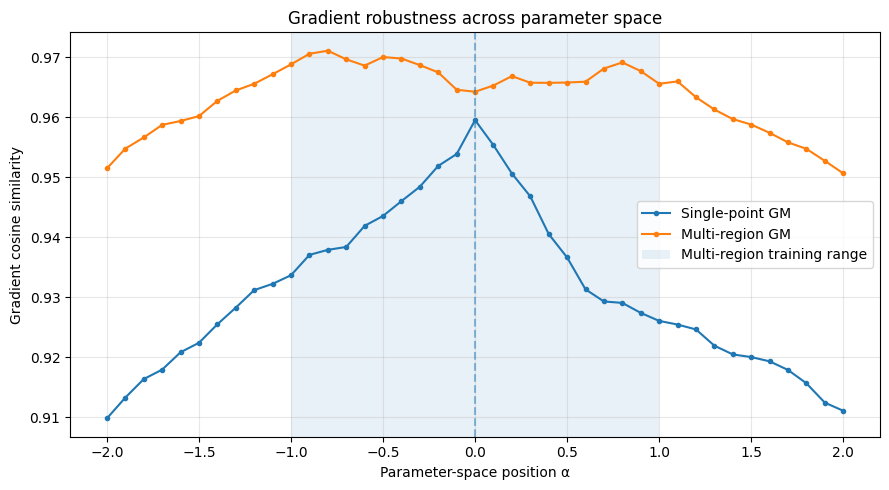

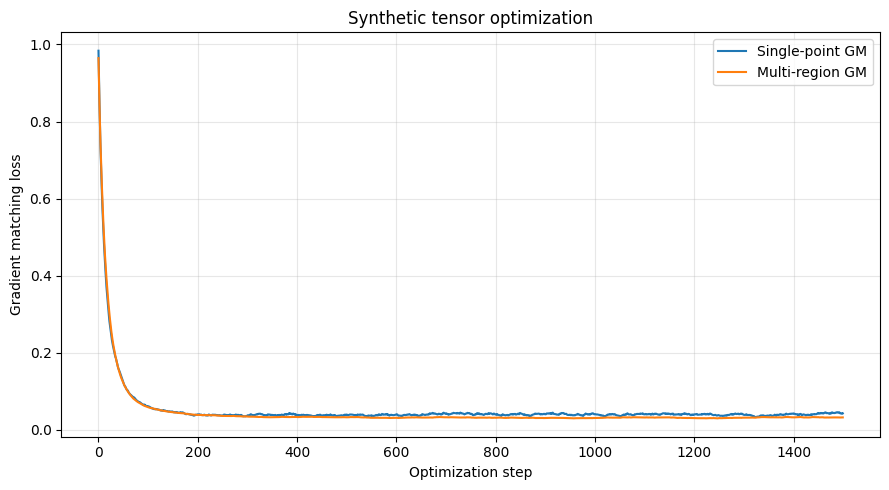


Saved:
  synthetic_single.pt
  synthetic_multi.pt
  parameter_gradient_robustness.png
  gradient_matching_training.png


In [4]:
# ============================================================
# MNIST: Parameter-Space Gradient Robustness
#
# Question:
#
#   If synthetic tensor T matches X's gradient at theta_0,
#   does it continue to match when theta changes?
#
# Compare:
#
#   1. Single-point gradient matching
#   2. Multi-region gradient matching
#
# Evaluate along:
#
#   theta(alpha) = theta_0 + alpha * v
#
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# Configuration
# ============================================================

SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# Synthetic dataset
# ------------------------------------------------------------

NUM_SYNTH = 50

# ------------------------------------------------------------
# Network
# ------------------------------------------------------------

HIDDEN = 128

# ------------------------------------------------------------
# Real MNIST batch
# ------------------------------------------------------------

REAL_BATCH_SIZE = 500

# ------------------------------------------------------------
# Synthetic optimization
# ------------------------------------------------------------

STEPS = 1500
LR = 0.05

# ------------------------------------------------------------
# Multi-region training
# ------------------------------------------------------------

NUM_MULTI_REGIONS = 16

# alpha values used during multi-region training
TRAIN_ALPHAS = np.linspace(
    -1.0,
    1.0,
    NUM_MULTI_REGIONS
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

TEST_ALPHAS = np.linspace(
    -2.0,
    2.0,
    41
)

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

PRINT_EVERY = 100


# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", DEVICE)


# ============================================================
# Model
# ============================================================

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            784,
            HIDDEN
        )

        self.fc2 = nn.Linear(
            HIDDEN,
            10
        )

    def forward(self, x):

        x = F.relu(
            self.fc1(x)
        )

        return self.fc2(x)


# ============================================================
# Soft cross entropy
# ============================================================

def soft_cross_entropy(
    logits,
    targets
):

    log_probs = F.log_softmax(
        logits,
        dim=1
    )

    return -(
        targets * log_probs
    ).sum(dim=1).mean()


# ============================================================
# Convert model to parameter tuple
# ============================================================

def get_parameters(model):

    return tuple(
        p.detach().clone()
        for p in model.parameters()
    )


# ============================================================
# theta(alpha)
#
# theta(alpha) = theta0 + alpha * direction
# ============================================================

def make_theta(
    theta0,
    direction,
    alpha
):

    return tuple(
        (
            p0 + alpha * d
        ).requires_grad_(True)
        for p0, d in zip(
            theta0,
            direction
        )
    )


# ============================================================
# Functional forward
# ============================================================

def functional_forward(
    x,
    params
):

    w1, b1, w2, b2 = params

    h = F.linear(
        x,
        w1,
        b1
    )

    h = F.relu(h)

    logits = F.linear(
        h,
        w2,
        b2
    )

    return logits


# ============================================================
# Compute gradient
# ============================================================

def compute_gradient(
    params,
    x,
    y,
    create_graph=False
):

    logits = functional_forward(
        x,
        params
    )

    loss = soft_cross_entropy(
        logits,
        y
    )

    grads = torch.autograd.grad(
        loss,
        params,
        create_graph=create_graph
    )

    return torch.cat([
        g.reshape(-1)
        for g in grads
    ])


# ============================================================
# Cosine distance
# ============================================================

def gradient_loss(
    g_syn,
    g_real
):

    g_syn = g_syn / (
        g_syn.norm() + 1e-8
    )

    g_real = g_real / (
        g_real.norm() + 1e-8
    )

    cosine = (
        g_syn * g_real
    ).sum()

    # cosine distance
    return 1.0 - cosine


# ============================================================
# Cosine similarity
# ============================================================

def cosine_similarity(
    a,
    b
):

    a = a / (
        a.norm() + 1e-8
    )

    b = b / (
        b.norm() + 1e-8
    )

    return (
        a * b
    ).sum().item()


# ============================================================
# Load MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True
)


# ============================================================
# FIX ONE REAL MNIST BATCH
#
# This is important.
#
# Every theta(alpha) sees exactly the same X.
# ============================================================

x_real, y_real = next(
    iter(train_loader)
)

x_real = x_real.reshape(
    x_real.size(0),
    -1
).to(DEVICE)

y_real = F.one_hot(
    y_real,
    num_classes=10
).float().to(DEVICE)


print(
    "Real batch:",
    x_real.shape,
    y_real.shape
)


# ============================================================
# Base model theta_0
# ============================================================

base_model = MLP().to(DEVICE)

theta0 = get_parameters(
    base_model
)


# ============================================================
# Create ONE parameter-space direction
#
# We normalize the direction so alpha has a meaningful
# interpretation.
# ============================================================

raw_direction = tuple(
    torch.randn_like(p)
    for p in theta0
)


# Compute total norm

direction_norm = torch.sqrt(
    sum(
        (d ** 2).sum()
        for d in raw_direction
    )
)


direction = tuple(
    d / (
        direction_norm + 1e-8
    )
    for d in raw_direction
)


# Scale direction relative to theta0 norm
theta_norm = torch.sqrt(
    sum(
        (p ** 2).sum()
        for p in theta0
    )
)

direction = tuple(
    d * theta_norm
    for d in direction
)


# ============================================================
# Synthetic initialization
# ============================================================

def initialize_synthetic():

    synthetic_x = torch.randn(
        NUM_SYNTH,
        784,
        device=DEVICE,
        requires_grad=True
    )

    synthetic_y_logits = torch.randn(
        NUM_SYNTH,
        10,
        device=DEVICE,
        requires_grad=True
    )

    return (
        synthetic_x,
        synthetic_y_logits
    )


# ============================================================
# Train synthetic dataset
#
# mode = "single"
# mode = "multi"
# ============================================================

def train_synthetic(
    mode
):

    synthetic_x, synthetic_y_logits = (
        initialize_synthetic()
    )

    optimizer = torch.optim.Adam(
        [
            synthetic_x,
            synthetic_y_logits
        ],
        lr=LR
    )

    history = []

    if mode == "single":

        train_alphas = [0.0]

    elif mode == "multi":

        train_alphas = TRAIN_ALPHAS

    else:

        raise ValueError(
            "Unknown mode"
        )


    # --------------------------------------------------------
    # Optimization
    # --------------------------------------------------------

    for step in range(STEPS):

        optimizer.zero_grad()

        synthetic_y = F.softmax(
            synthetic_y_logits,
            dim=1
        )

        total_loss = 0.0

        for alpha in train_alphas:

            # ----------------------------------------------
            # Current parameter
            # ----------------------------------------------

            theta = make_theta(
                theta0,
                direction,
                float(alpha)
            )

            # ----------------------------------------------
            # Real gradient
            #
            # create_graph=False because the real gradient
            # is a target and does not need optimization.
            # ----------------------------------------------

            g_real = compute_gradient(
                theta,
                x_real,
                y_real,
                create_graph=False
            )

            g_real = g_real.detach()

            # ----------------------------------------------
            # Synthetic gradient
            #
            # create_graph=True is critical.
            #
            # We need:
            #
            # d/dT [
            #     gradient_distance(
            #       grad_theta L(T),
            #       grad_theta L(X)
            #     )
            # ]
            # ----------------------------------------------

            g_syn = compute_gradient(
                theta,
                synthetic_x,
                synthetic_y,
                create_graph=True
            )

            loss = gradient_loss(
                g_syn,
                g_real
            )

            total_loss = (
                total_loss + loss
            )

        total_loss = (
            total_loss /
            len(train_alphas)
        )

        total_loss.backward()

        optimizer.step()

        # Keep image values bounded
        with torch.no_grad():

            synthetic_x.clamp_(
                -3.0,
                3.0
            )

        history.append(
            total_loss.item()
        )

        if step % PRINT_EVERY == 0:

            print(
                f"[{mode}] "
                f"step={step:4d} "
                f"loss={total_loss.item():.6f}"
            )

    return {
        "x": synthetic_x.detach(),
        "y_logits": synthetic_y_logits.detach(),
        "loss": history
    }


# ============================================================
# Train Single-point T
# ============================================================

print()
print("=" * 70)
print("Training SINGLE-POINT synthetic tensor")
print("=" * 70)

single_result = train_synthetic(
    "single"
)


# ============================================================
# Train Multi-region T
# ============================================================

print()
print("=" * 70)
print("Training MULTI-REGION synthetic tensor")
print("=" * 70)

multi_result = train_synthetic(
    "multi"
)


# ============================================================
# Evaluate along parameter trajectory
# ============================================================

def evaluate_along_trajectory(
    result
):

    synthetic_x = result["x"]

    synthetic_y = F.softmax(
        result["y_logits"],
        dim=1
    )

    similarities = []

    for alpha in TEST_ALPHAS:

        # ----------------------------------------------------
        # theta(alpha)
        # ----------------------------------------------------

        theta = make_theta(
            theta0,
            direction,
            float(alpha)
        )

        # ----------------------------------------------------
        # Gradient from real MNIST batch
        # ----------------------------------------------------

        g_real = compute_gradient(
            theta,
            x_real,
            y_real,
            create_graph=False
        ).detach()

        # ----------------------------------------------------
        # Gradient from synthetic tensor
        # ----------------------------------------------------

        g_syn = compute_gradient(
            theta,
            synthetic_x,
            synthetic_y,
            create_graph=False
        ).detach()

        # ----------------------------------------------------
        # Similarity
        # ----------------------------------------------------

        similarity = cosine_similarity(
            g_syn,
            g_real
        )

        similarities.append(
            similarity
        )

    return np.array(
        similarities
    )


print()
print("=" * 70)
print("Evaluating parameter-space robustness")
print("=" * 70)

single_similarity = (
    evaluate_along_trajectory(
        single_result
    )
)

multi_similarity = (
    evaluate_along_trajectory(
        multi_result
    )
)


# ============================================================
# Print table
# ============================================================

print()

print(
    f"{'alpha':>8} | "
    f"{'Single':>12} | "
    f"{'Multi':>12}"
)

print("-" * 40)

for alpha, s, m in zip(
    TEST_ALPHAS,
    single_similarity,
    multi_similarity
):

    print(
        f"{alpha:8.2f} | "
        f"{s:12.5f} | "
        f"{m:12.5f}"
    )


# ============================================================
# Summary statistics
# ============================================================

# In-distribution:
# alpha in [-1, 1]

train_mask = (
    np.abs(TEST_ALPHAS) <= 1.0
)

# Out-of-distribution:
# alpha in (1, 2] or [-2, -1)

ood_mask = (
    np.abs(TEST_ALPHAS) > 1.0
)


print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print()

print(
    "Single-point:"
)

print(
    "  mean similarity [-1,1] =",
    single_similarity[
        train_mask
    ].mean()
)

print(
    "  mean similarity outside =",
    single_similarity[
        ood_mask
    ].mean()
)

print()

print(
    "Multi-region:"
)

print(
    "  mean similarity [-1,1] =",
    multi_similarity[
        train_mask
    ].mean()
)

print(
    "  mean similarity outside =",
    multi_similarity[
        ood_mask
    ].mean()
)


# ============================================================
# Plot 1
#
# Gradient similarity vs parameter position
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    TEST_ALPHAS,
    single_similarity,
    marker="o",
    markersize=3,
    label="Single-point GM"
)

plt.plot(
    TEST_ALPHAS,
    multi_similarity,
    marker="o",
    markersize=3,
    label="Multi-region GM"
)

# Training interval
plt.axvspan(
    -1,
    1,
    alpha=0.10,
    label="Multi-region training range"
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel(
    "Parameter-space position α"
)

plt.ylabel(
    "Gradient cosine similarity"
)

plt.title(
    "Gradient robustness across parameter space"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "parameter_gradient_robustness.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot 2
#
# Training loss
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    single_result["loss"],
    label="Single-point GM"
)

plt.plot(
    multi_result["loss"],
    label="Multi-region GM"
)

plt.xlabel(
    "Optimization step"
)

plt.ylabel(
    "Gradient matching loss"
)

plt.title(
    "Synthetic tensor optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "gradient_matching_training.png",
    dpi=150
)

plt.show()


# ============================================================
# Save synthetic tensors
# ============================================================

torch.save(
    {
        "x": single_result["x"].cpu(),
        "y_logits": single_result[
            "y_logits"
        ].cpu()
    },
    "synthetic_single.pt"
)

torch.save(
    {
        "x": multi_result["x"].cpu(),
        "y_logits": multi_result[
            "y_logits"
        ].cpu()
    },
    "synthetic_multi.pt"
)


print()
print("Saved:")
print("  synthetic_single.pt")
print("  synthetic_multi.pt")
print("  parameter_gradient_robustness.png")
print("  gradient_matching_training.png")